# Model example of UltraNest + SMBHB

In [66]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
# Built-in
import os
import json
import datetime

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path

# UltraNest packages
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

# PlatoSim libraries
import platosim.smbhb as smbhb
import platosim.utilities as ut
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In [68]:
# Paths to where data is stored
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
fdir = path / 'figures'
rdir = path / 'results'

---
## 1. White-noise light curve of Spikey
---

### Create input model

First we create a time array for the model:

In [69]:
tdur = 3 * ut.year() / 86400
dt   = 1
time = smbhb.time(tdur, dt)

Model parameters of Spikey (Hu+2020, Table 1)

In [70]:
# All unit are CGS or normalised
M1 = 10**7.4 # [M_sun]
M2 = 10**6.7 # [M_sun]
z     = 0.962
t0    = 1.050
P     = 1.144
i     = np.rad2deg(np.arccos(0.140))
e     = 0.524
w     = np.rad2deg(1.477)
logM  = np.log10(M2 + M1)
q     = M2 / M1
L     = 0.89
alpha = 2.09
vz    = 0
tau   = 50   # [day] (434 days paper)
sigma = 100  # [ppm] (3400 ppm paper)

Initialise model parameters:

In [71]:
params = smbhb.model_params()
params.z     = z
params.t0    = t0
params.P     = P
params.i     = i
params.e     = e
params.w     = w
params.logM  = logM
params.q     = q
params.L     = L
params.alpha = alpha
params.vz    = vz
params.tau   = tau
params.sigma = sigma  
params.seed  = 123456789

Initialise model with model parameters:

In [72]:
model = smbhb.model(params)

Generate the light curve model:

In [73]:
flux, flux_boost, flux_lens, flux_red = model.light_curve(time)

Create data frame with model time series:

In [74]:
dv = pd.DataFrame()
dv['time'] = time
dv['flux'] = flux

Create data frame with model components and plot it:

<IPython.core.display.Javascript object>


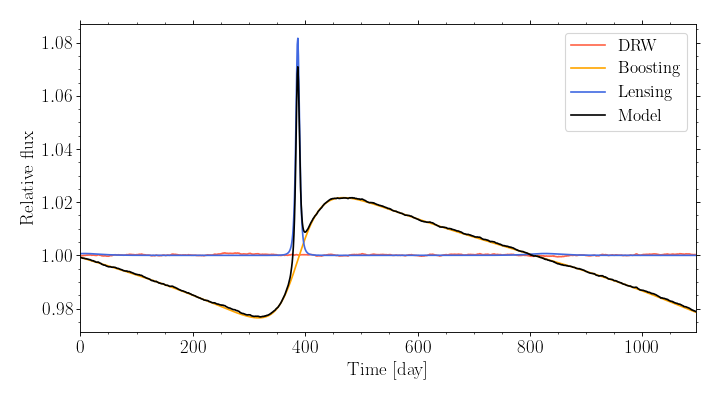

In [75]:
dm = dv.copy()
dm['flux_red'] = flux_red
dm['flux_boost'] = flux_boost
dm['flux_lens'] = flux_lens
smbhb.plot_model(dm); 

Add some Gaussian noise to to the model:

<IPython.core.display.Javascript object>


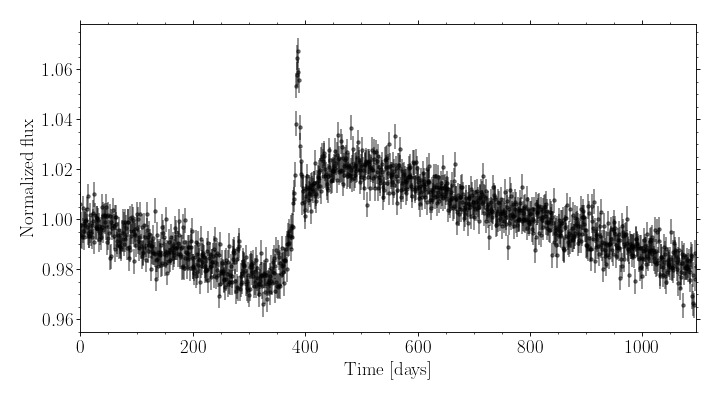

In [76]:
df = dv.copy()
noise_level = 5e-3  # [pp1]
df.flux += np.random.normal(0, noise_level, len(time))
df['flux_err'] = np.full(df.shape[0], noise_level)
smbhb.plot_lc(df); 

### Model with UltraNest + SMBHB

Define priors:

In [77]:
priors = smbhb.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0.8, 1.3]
priors.i     = [50, 90]
priors.e     = [0.3, 0.6]
priors.w     = [70, 100]
priors.logM  = [6, 9]
priors.q     = [0, 1]
priors.L     = [0, 1]
priors.alpha = [alpha*0.8, alpha*1.2]
priors.vz    = vz

Run UltraNest on our simulated light curve:

In [78]:
result, sampler = smbhb.run_ultranest(df, priors, rdir, nsteps=1000, live_points=1000)

[ultranest] Sampling 1000 live points from prior ...


[ultranest] Explored until L=-5e+02  .64 [-528.4652..-528.4651]*| it/evals=30127/2639240 eff=1.1419% N=1000  00     
[ultranest] Likelihood function evaluations: 2639240
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -553.8 +- 0.09954
[ultranest] Effective samples strategy satisfied (ESS = 7145.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.03 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.10, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.10 tail:0.01 total:0.10 required:<0.50
[ultranest] done iterating.
Execution time: 0:17:16.064559 [h:mm:ss]

logZ = -553.781 +- 0.142
  single instance: logZ = -553.781 +- 0.149
  bootstrapped   : logZ = -553.807 +- 0.142
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jump distance 0.95 (should be >1), f

In [79]:
# result

Plot best-fit light curve

<IPython.core.display.Javascript object>


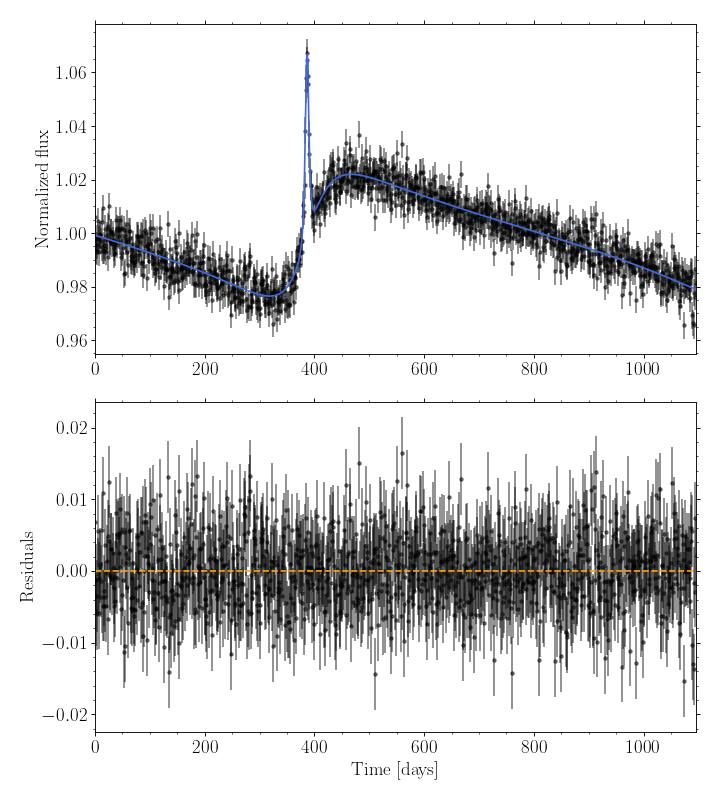

(<Figure size 900x1000 with 2 Axes>,
 array([<Axes: ylabel='Normalized flux'>,
        <Axes: xlabel='Time [days]', ylabel='Residuals'>], dtype=object))

In [80]:
smbhb.plot_result(df, result, z)

Make a pretty corner plot:

<IPython.core.display.Javascript object>


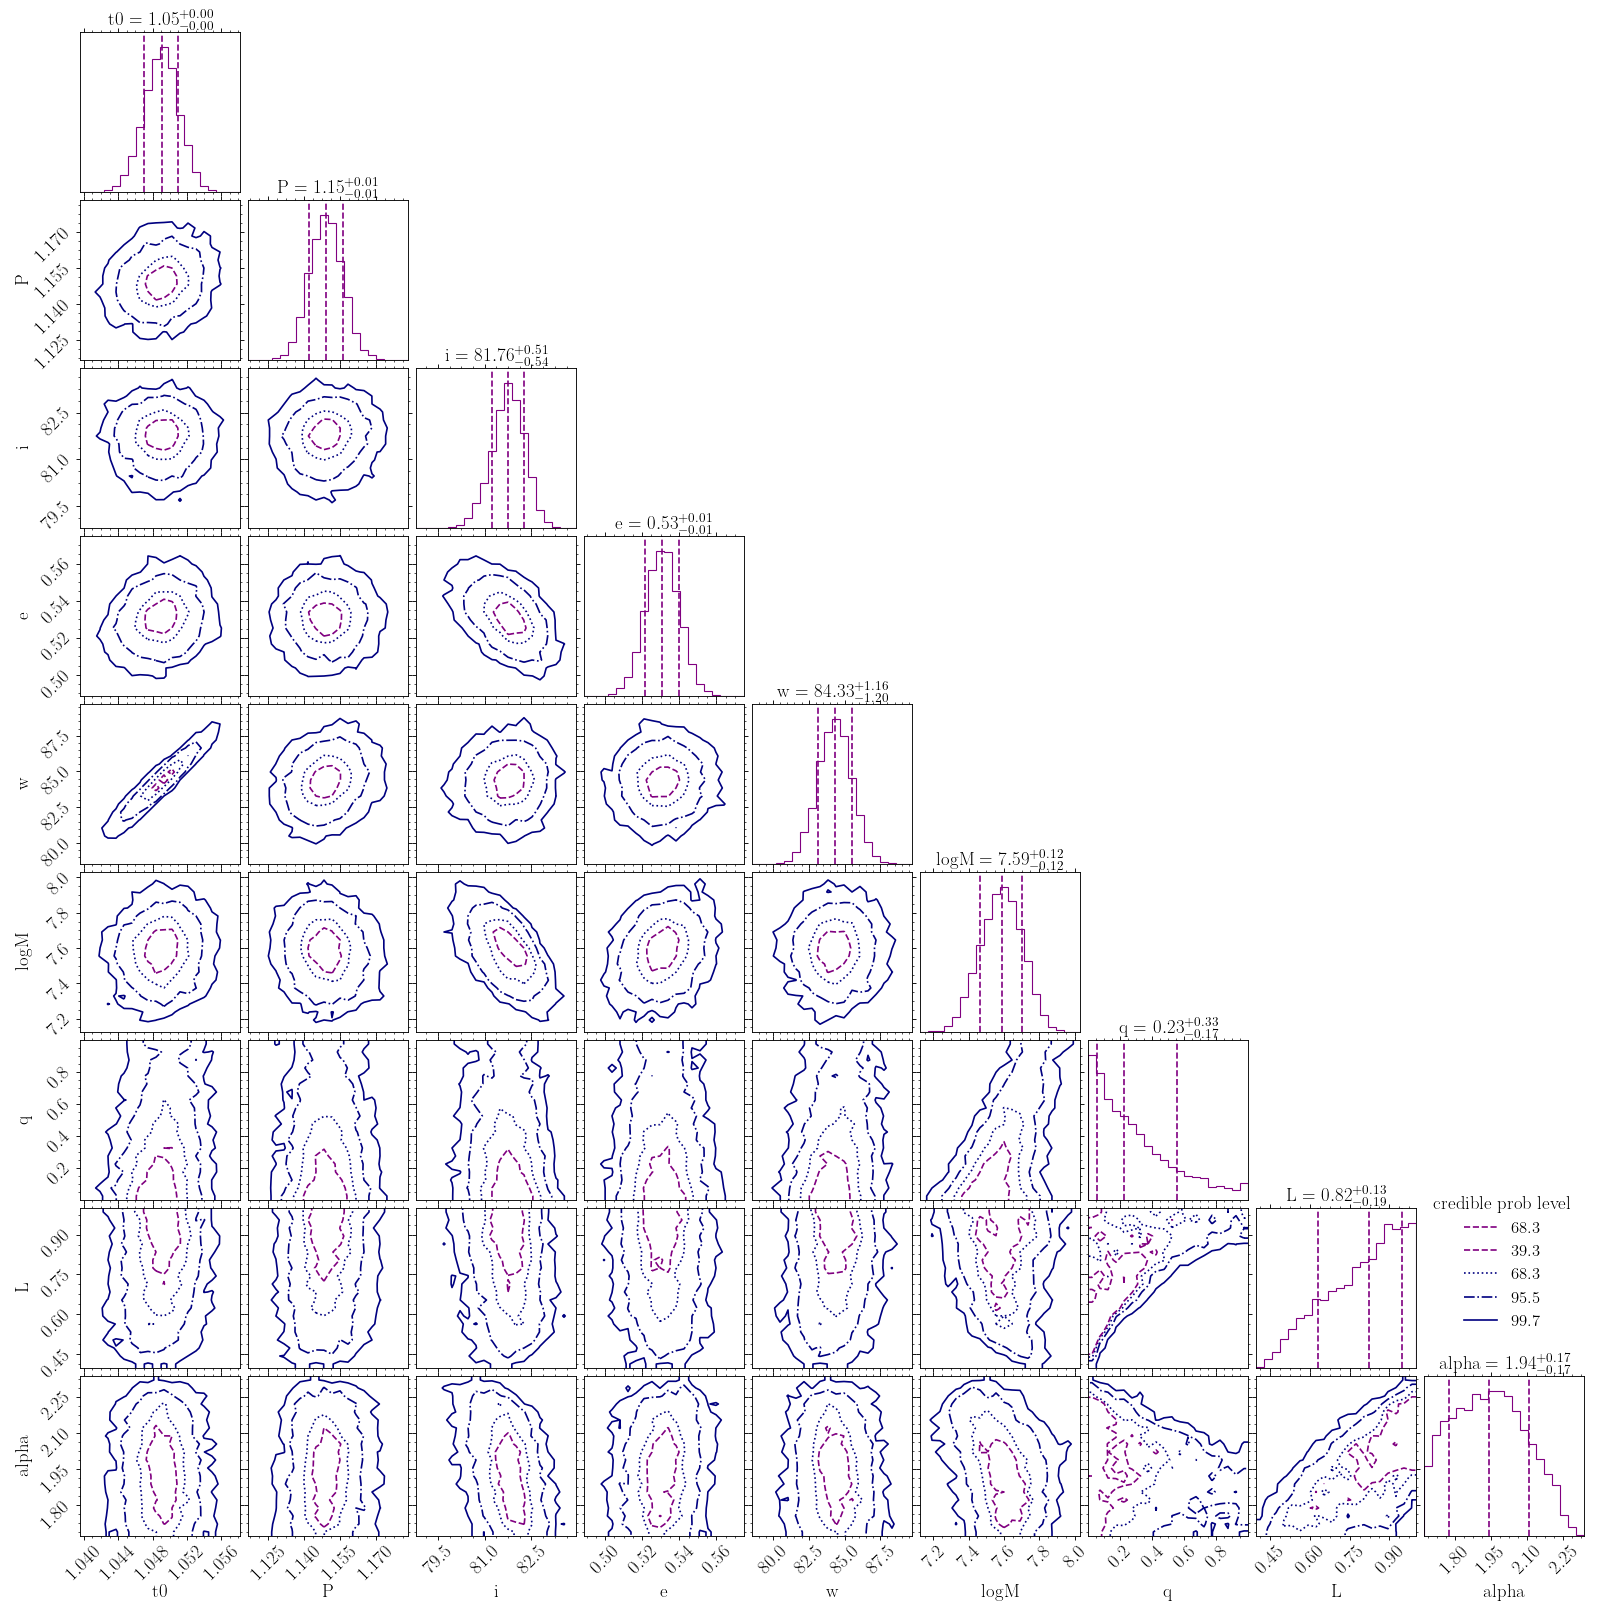

In [81]:
smbhb.plot_corner(result)

Timing of different runs:

In [82]:
# Default setup:
# z = params.z
# t_lo, t_hi = 0.9, 1.1  # 1.05
# P_lo, P_hi = 1.0, 1.2  # 1.114
# i_lo, i_hi = 70.0, 90.0  # 81.952
# e_lo, e_hi = 0.4, 0.6  # 0.524
# w_lo, w_hi = 50., 120.  # 84.6258
# M_lo, M_hi = 7, 8.     # 7.479
# q_lo, q_hi = 0.0, 0.3  # 0.1995
# L_lo, L_hi = 0.7, 1.0  # 0.89
# a_lo, a_hi = 0.1, 3.0  # 2.09
# vz = params.vz
# nsteps=1000, live_points=400
# Execution time: 0:04:37.861366 [h:mm:ss]
# logZ = -575.932 +- 0.321

In [83]:
# Changes: allowing int ranges (and not solely float)
# Execution time: 0:04:38.430958 [h:mm:ss]
# logZ = -575.996 +- 0.327

In [84]:
# Changes:
# q_lo, q_hi = 0, 1  # 0.1995
# L_lo, L_hi = 0, 1  # 0.89
# Execution time: 1:31:09.028804 [h:mm:ss]
# logZ = -576.347 +- 0.446

In [85]:
# Changes: live_points=1000
# Execution time: 0:27:46.053724 [h:mm:ss]
# logZ = -576.937 +- 0.220

---
## 2. PlatoSim light curve of Spikey
---